In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
import h5py
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from tqdm.notebook import tqdm
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from scipy.signal import find_peaks
import statsmodels.api as sm

import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

### ALL-OR-NONE + CODES BACKGROUND

In [3]:
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'
patch_fs_c14 = 50023.8986874656
#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec

In [4]:
#flip sign of patch filt
patch_filt_c14 = -patch_filt_c14

#### Example "raw" spike data

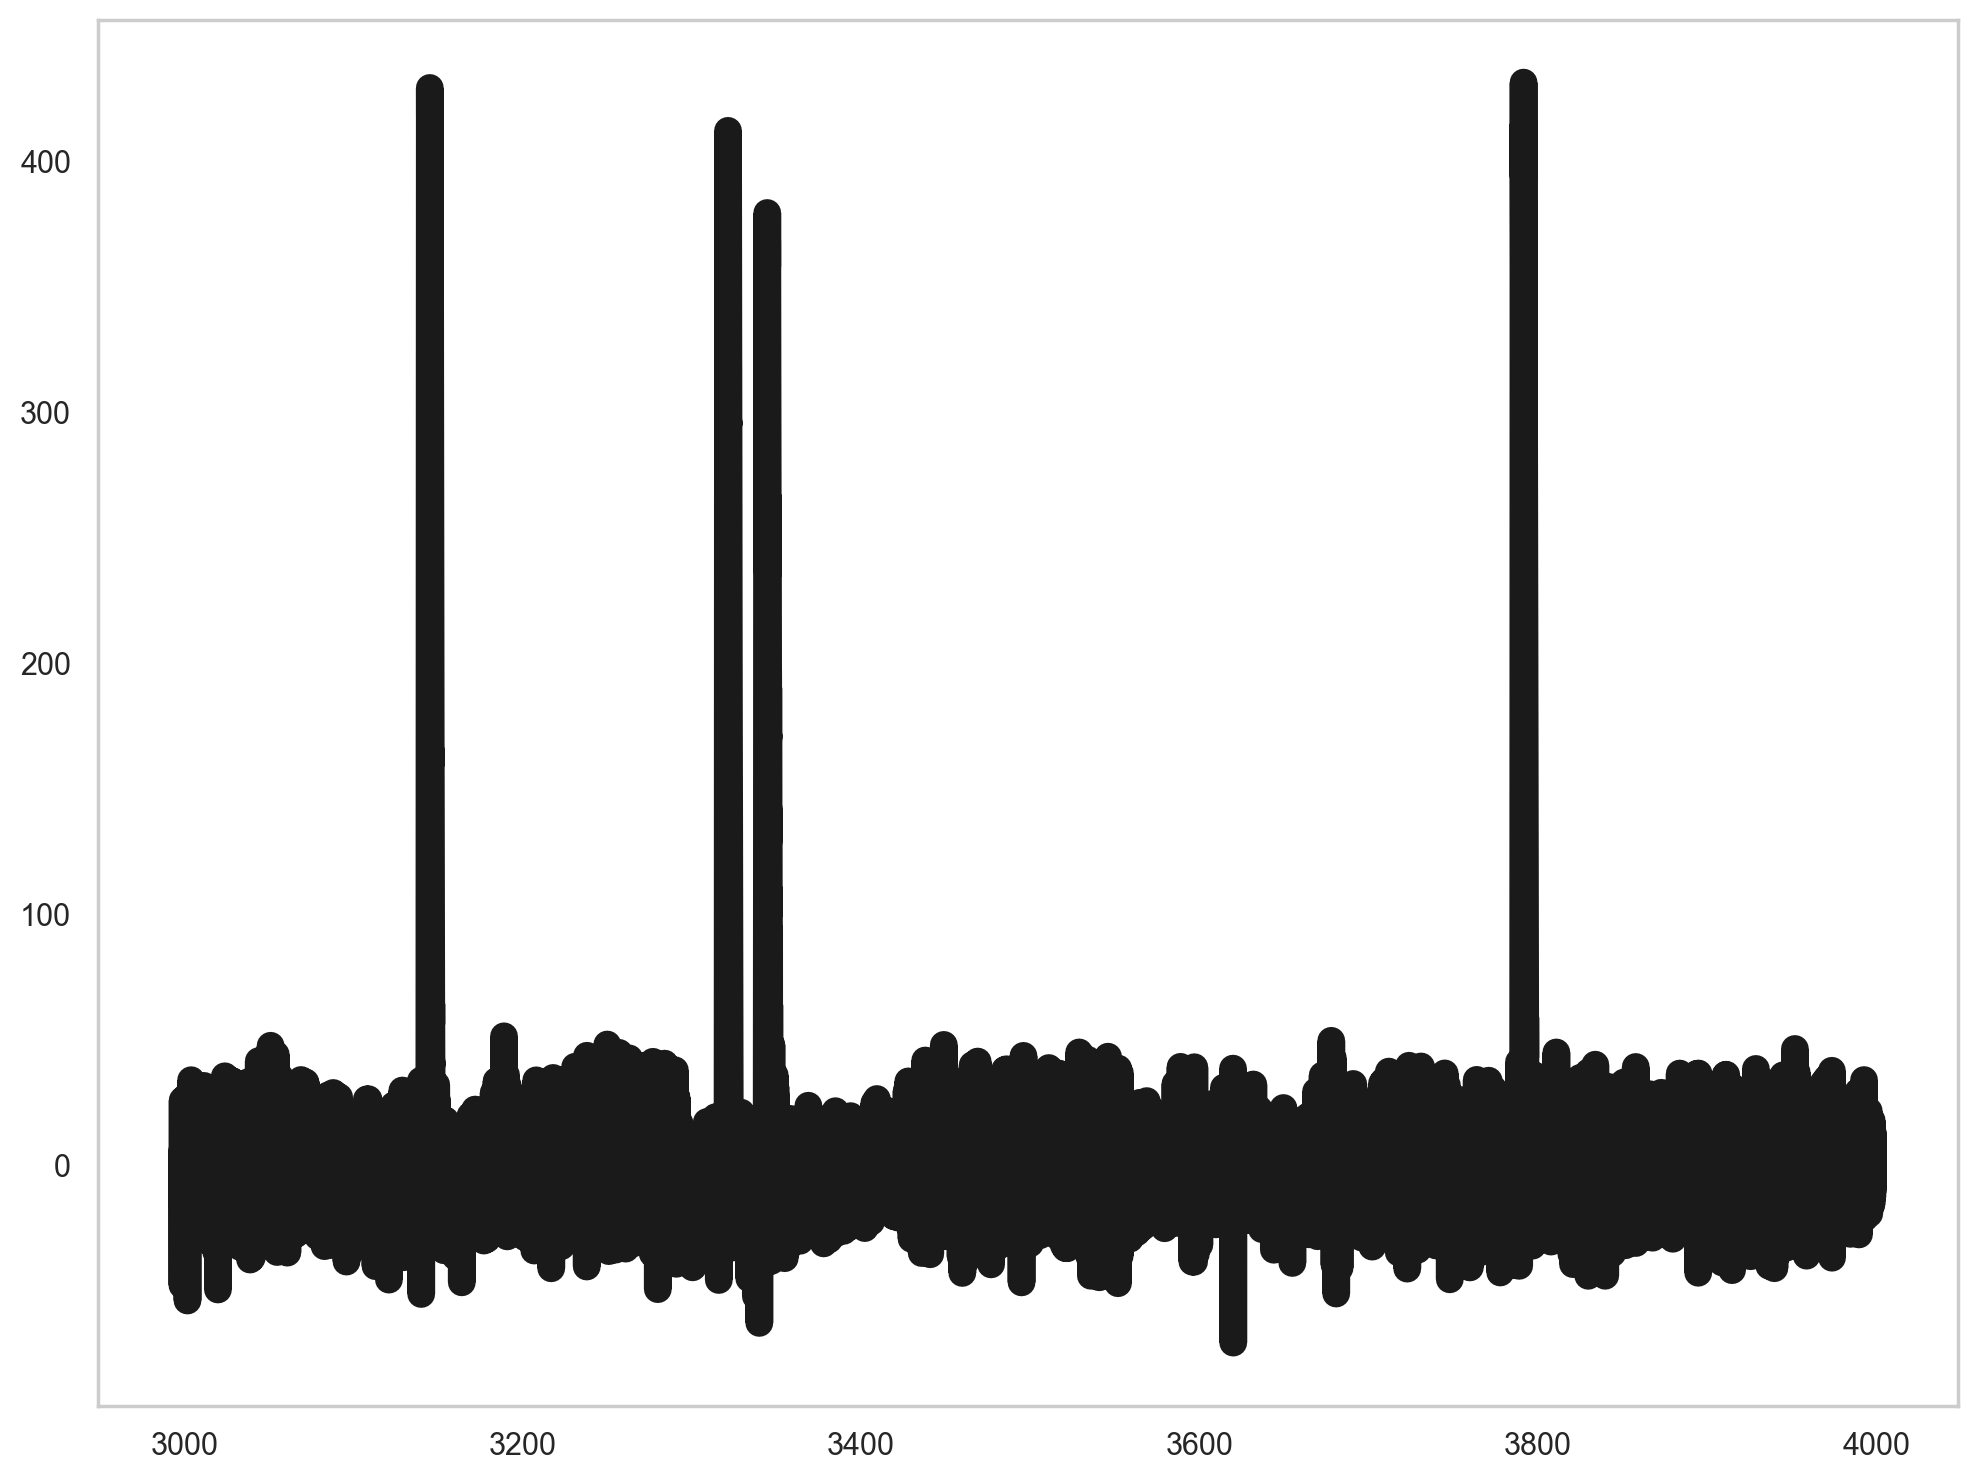

In [5]:
plt.plot(patch_times_c14[150000:200000], patch_filt_c14[150000:200000], color = 'k', linewidth=10)

#### Binarized version 

In [6]:
# Define a threshold, e.g., everything above 100 becomes 1, everything else 0
threshold = 100
binarized_data = np.where(patch_filt_c14[150000:200000] > threshold, 1, 0)

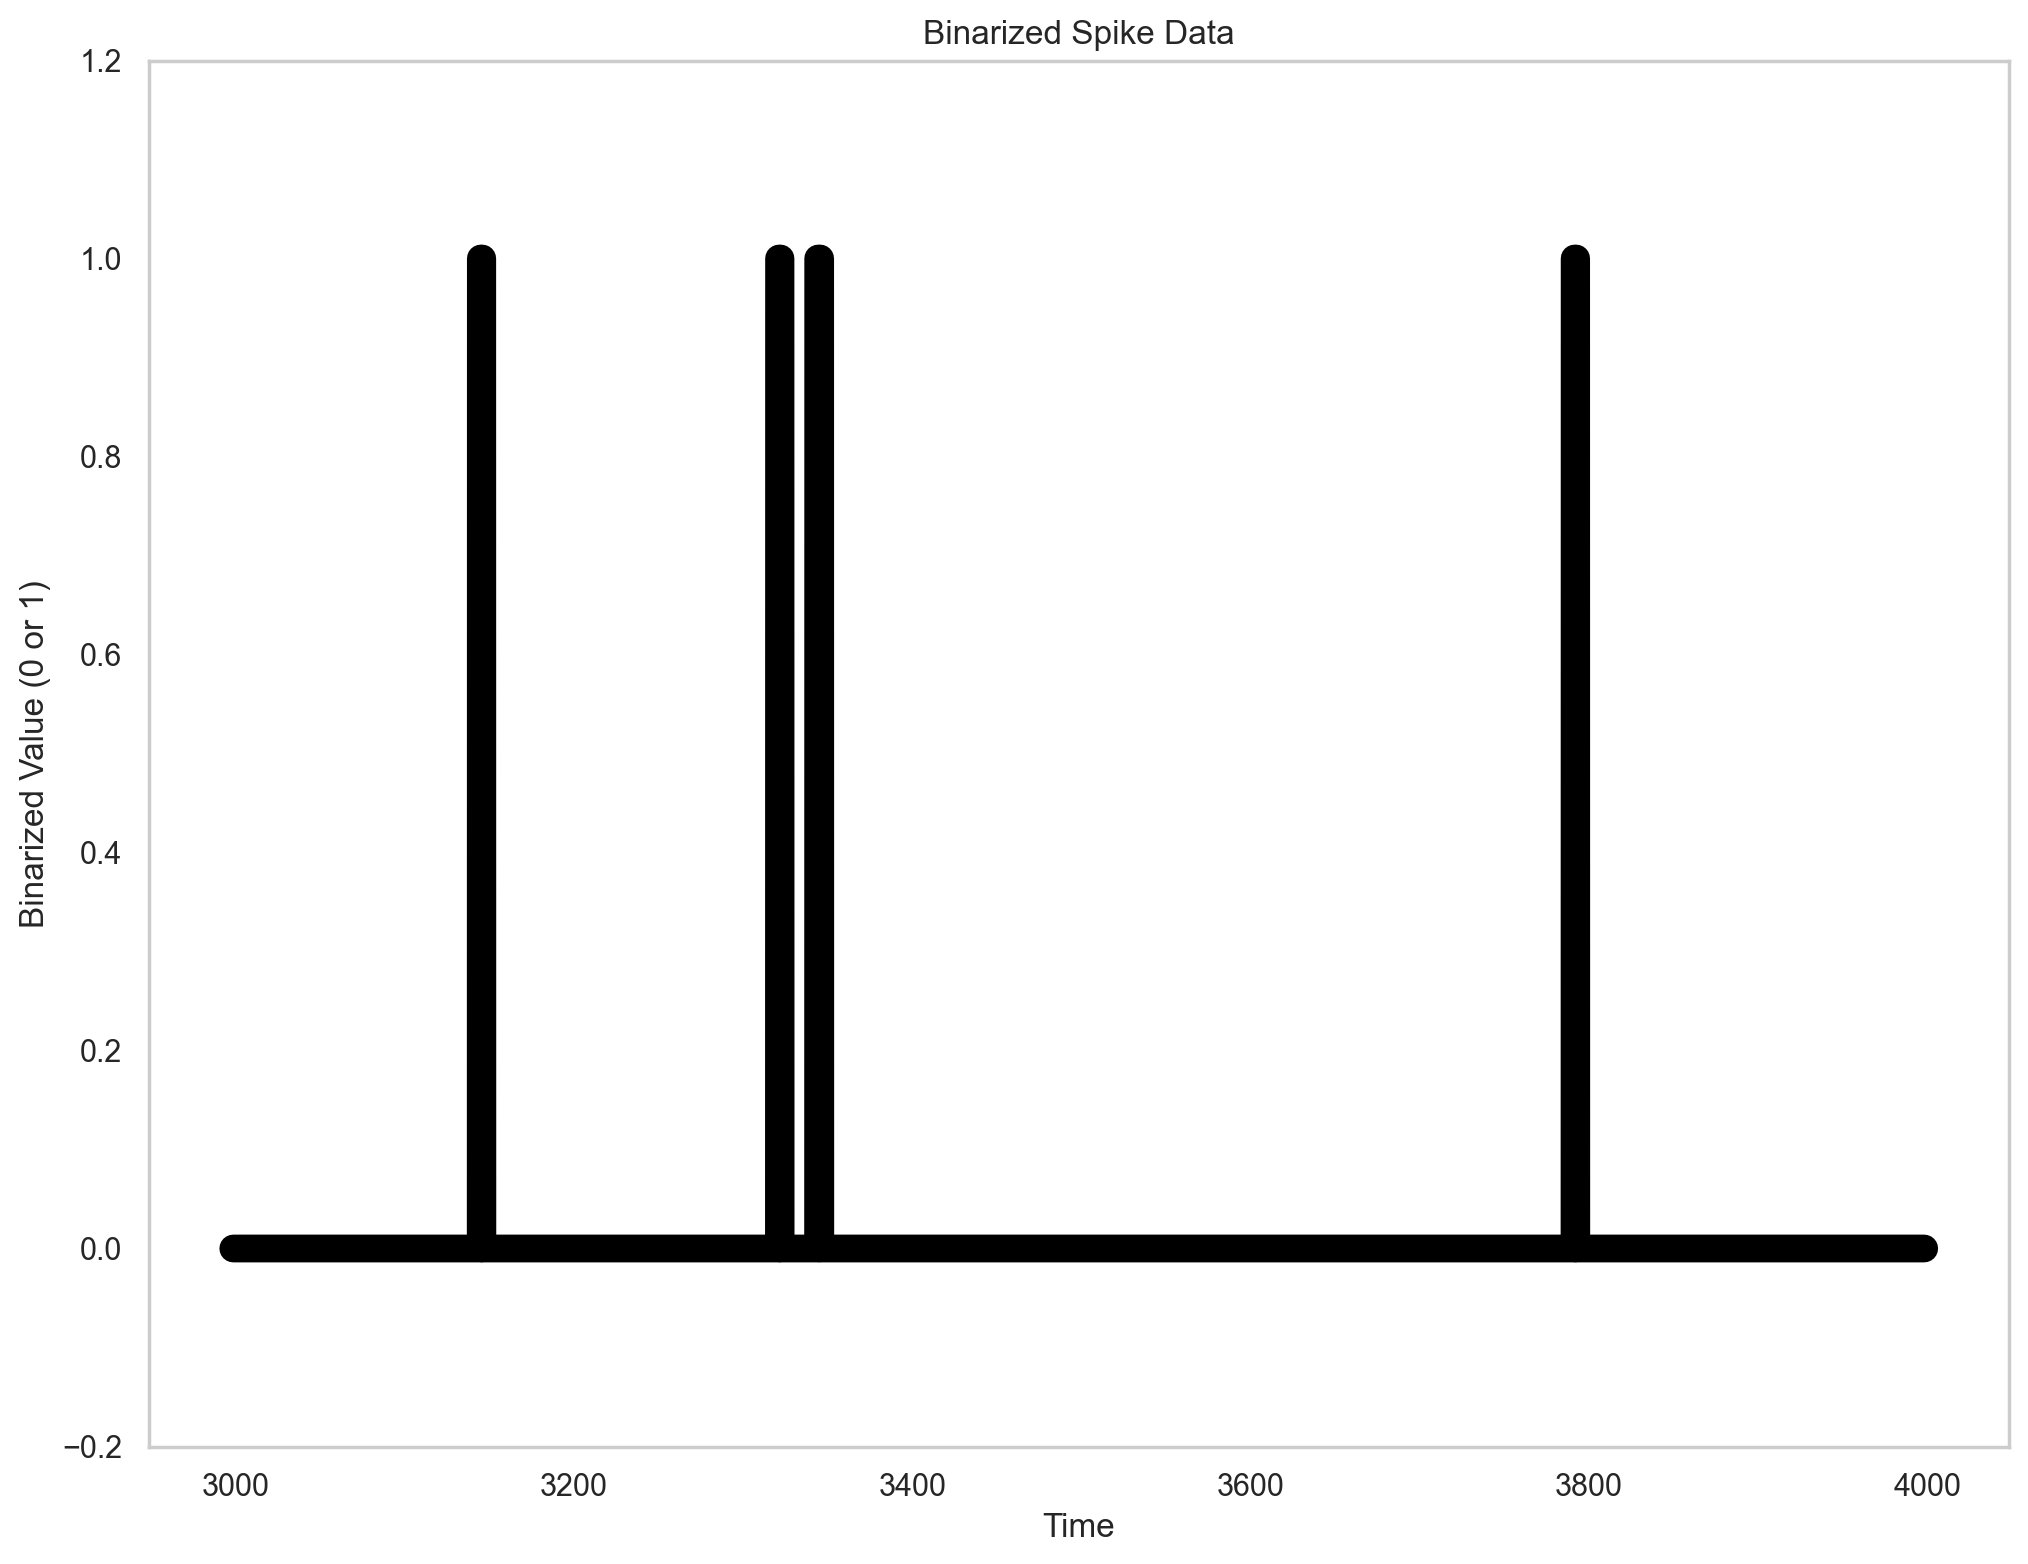

In [7]:
# Plot the binarized data

plt.plot(patch_times_c14[150000:200000], binarized_data, color='black', linewidth=10)
plt.title('Binarized Spike Data')
plt.xlabel('Time')
plt.ylabel('Binarized Value (0 or 1)')
plt.ylim(-0.2, 1.2)  # Keep the y-axis limits between -0.2 and 1.2 for clarity

plt.show()

#### Rate code figure 

In [8]:
# Define your window size (in samples). For example, a 10 ms window.
# Assuming your data is sampled at 1 kHz, a 10 ms window would be 10 samples.
window_size = 1  # adjust this depending on your sampling rate and desired window length

# Create a window for convolution
window = np.ones(window_size) / window_size

# Convolve the binarized data with the window to calculate the firing rate
firing_rate = np.convolve(binarized_data, window, mode='same')


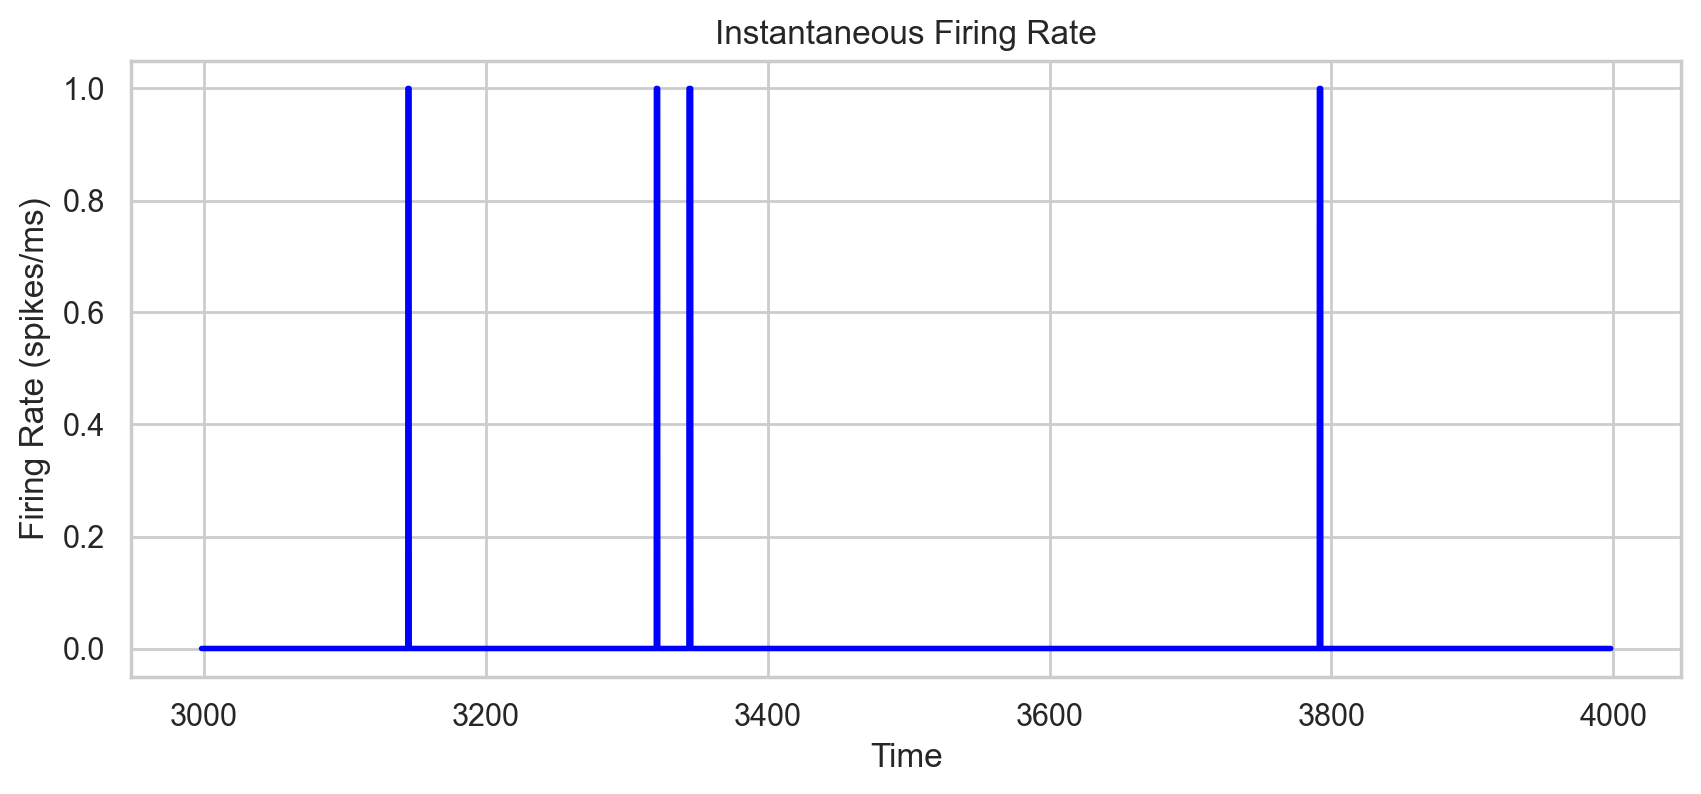

In [9]:
# Plot the firing rate
plt.figure(figsize=(10, 4))
plt.plot(patch_times_c14[150000:200000], firing_rate, color='blue', linewidth=2)
plt.title('Instantaneous Firing Rate')
plt.xlabel('Time')
plt.ylabel('Firing Rate (spikes/ms)')
plt.grid(True)
plt.show()

#### Temporal code figure 

#### Population code figure

### Toy parameterization example - pvc6 

In [10]:
# open and load the data

fs = 200000 # sampling rate
one_ms = int(fs / 1000)

total_sweeps = 66

filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename

# open file
f = h5py.File(filename, 'r')



In [11]:
# helper functions

# load sweeps
def load_sweep(sweep_number):
    # load sweep
    dset = f['Sweep_' + str(sweep_number)]

    # create array of time indices
    convert_to_ms = (fs / 1000)
    times = np.arange(0, np.shape(dset)[0]) / convert_to_ms # in ms instead of sec

    return dset, times



# find the spike times
def find_spike_times(data, thresh_mv, thresh_ms):
    # thresh_mv is the voltage threshold that needs to be crossed
    # thresh_ms is how many ms each peak needs to be from the next

    peaks = find_peaks(data, height=thresh_mv, distance=thresh_ms)
    idx_spikes = peaks[0] # spike indices
    amp_spikes = peaks[1]['peak_heights'] # spike amplitudes

    return idx_spikes, amp_spikes



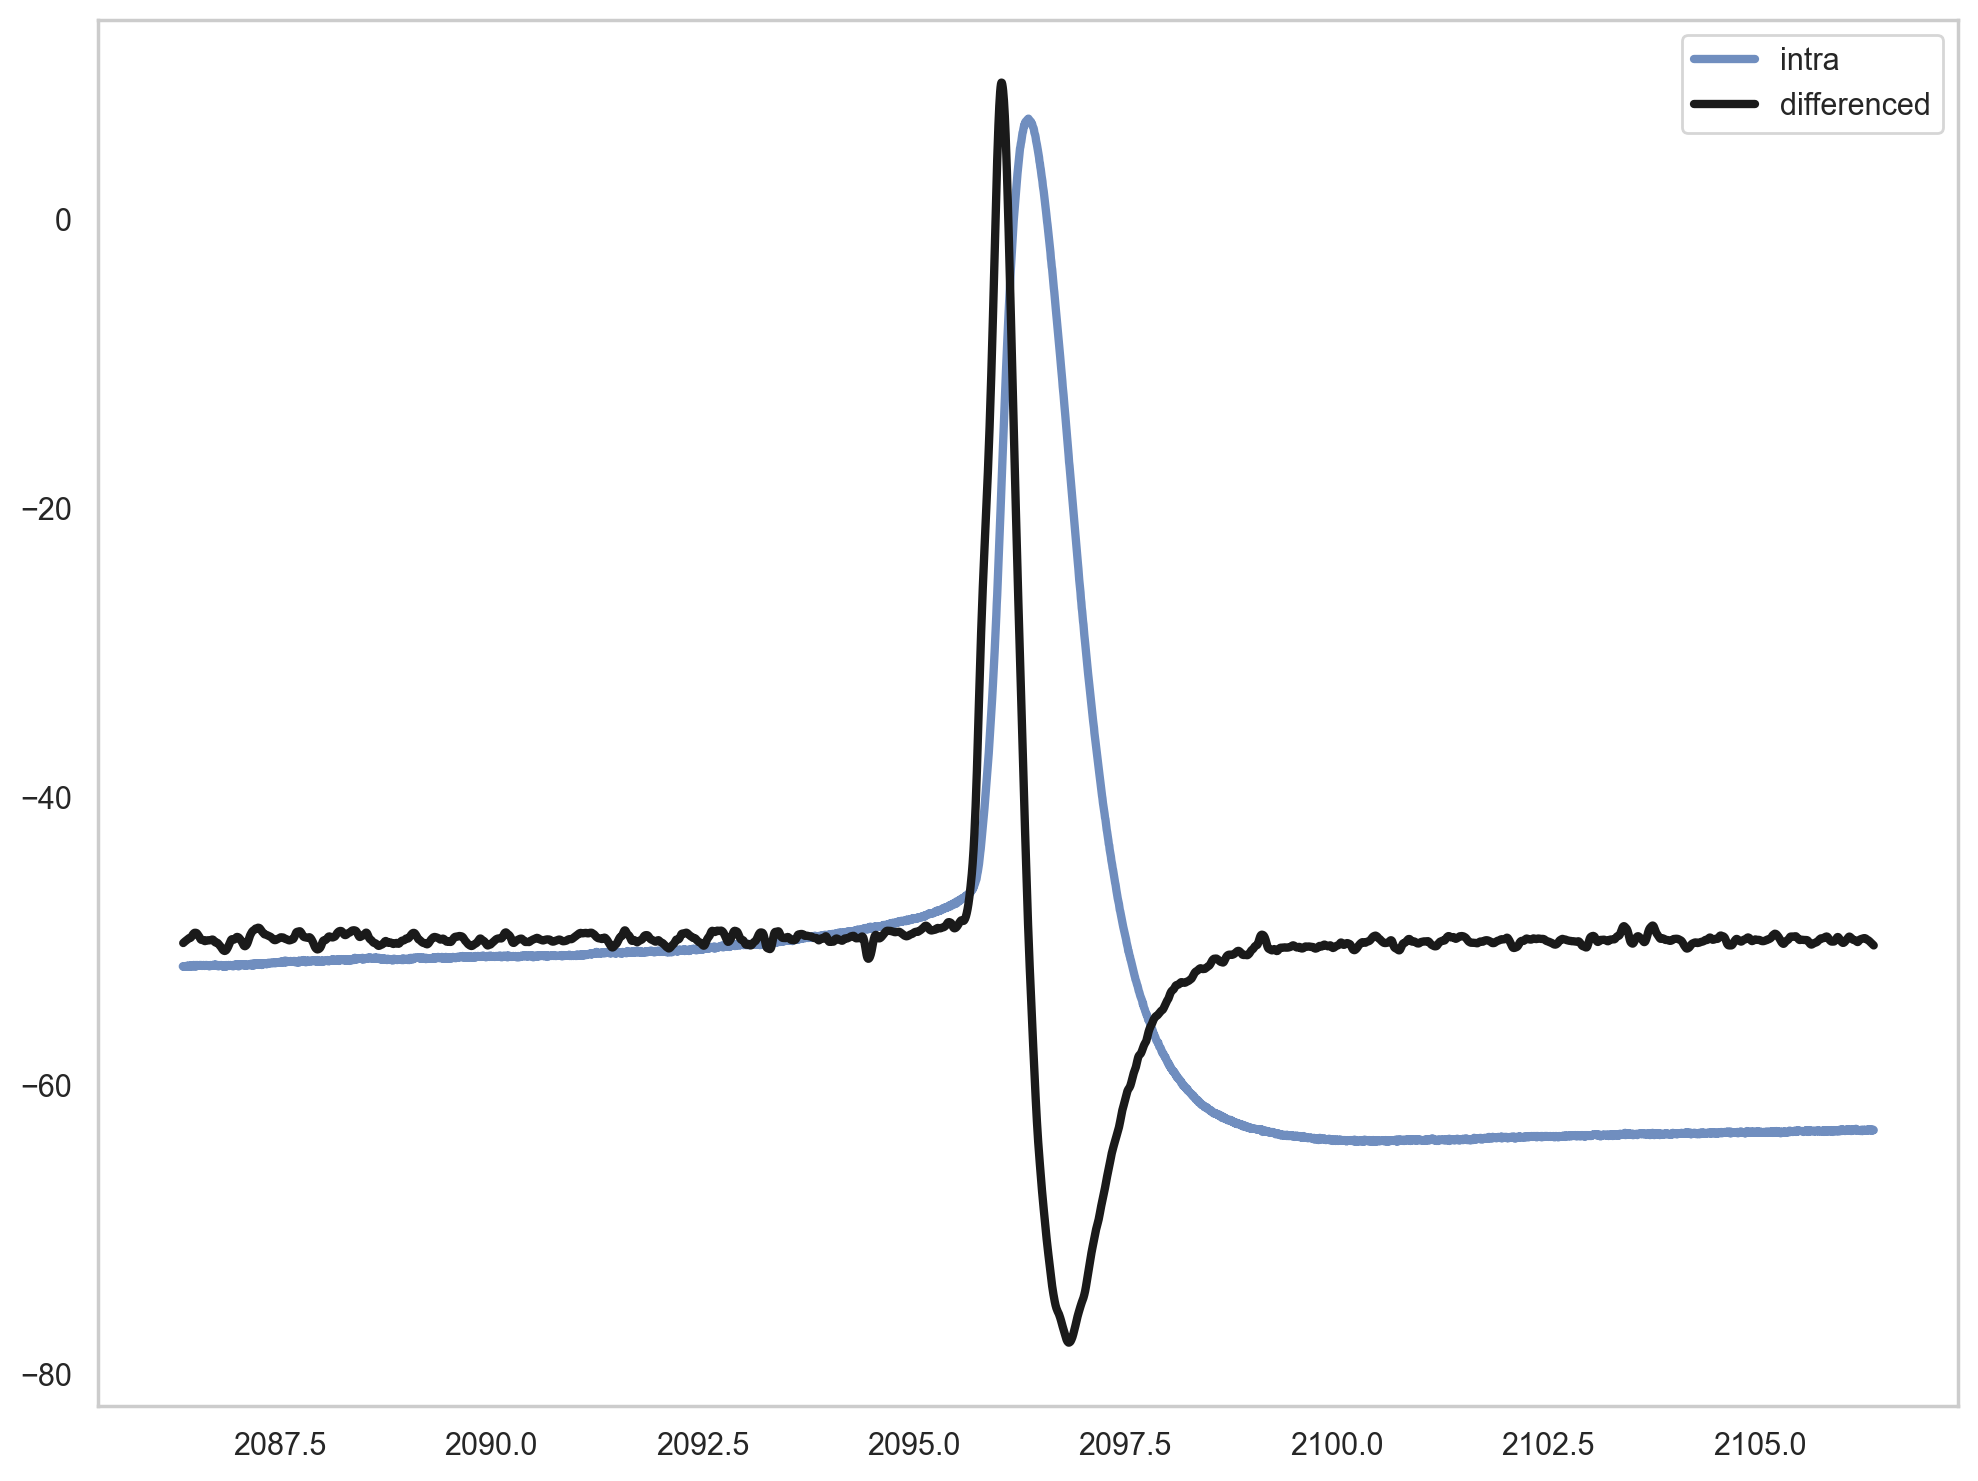

In [12]:
# Plot single spike, and its derivative
i_sweeps = 28
dset, times = load_sweep(i_sweeps)

stim = dset[:, 0] # current injection
data = dset[:, 1] # ephys data

#########################
# find spikes
thresh_mv = -10
thresh_ms = one_ms * 1 # 1 ms

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

#########################
i_spikes = 0
    
# get windows around spikes
# create window indices
window_length = (10, 10) # in ms
window_pre = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

# get window
window_spike_pre = (idx_spikes[i_spikes]-window_pre)
window_spike_post = (idx_spikes[i_spikes]+window_post)

# get window for times as well
windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                    (idx_spikes[i_spikes]+window_post)]

# get data window
windowed_data = data[window_spike_pre:window_spike_post]

# difference of data, and smooth it
d_windowed_data = np.diff(windowed_data)
smoothed_data = sm.nonparametric.lowess(d_windowed_data, windowed_times[1:], frac=0.008)

# smoothed data
d_smoothed_times = smoothed_data[:, 0]
d_smoothed_data = smoothed_data[:, 1]

plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 3., label='intra')
plt.plot(d_smoothed_times, (d_smoothed_data*80)-50, 'k', linewidth = 3., label='differenced')
plt.legend()
plt.show()

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_99791/3251282466.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 10.,color='k')


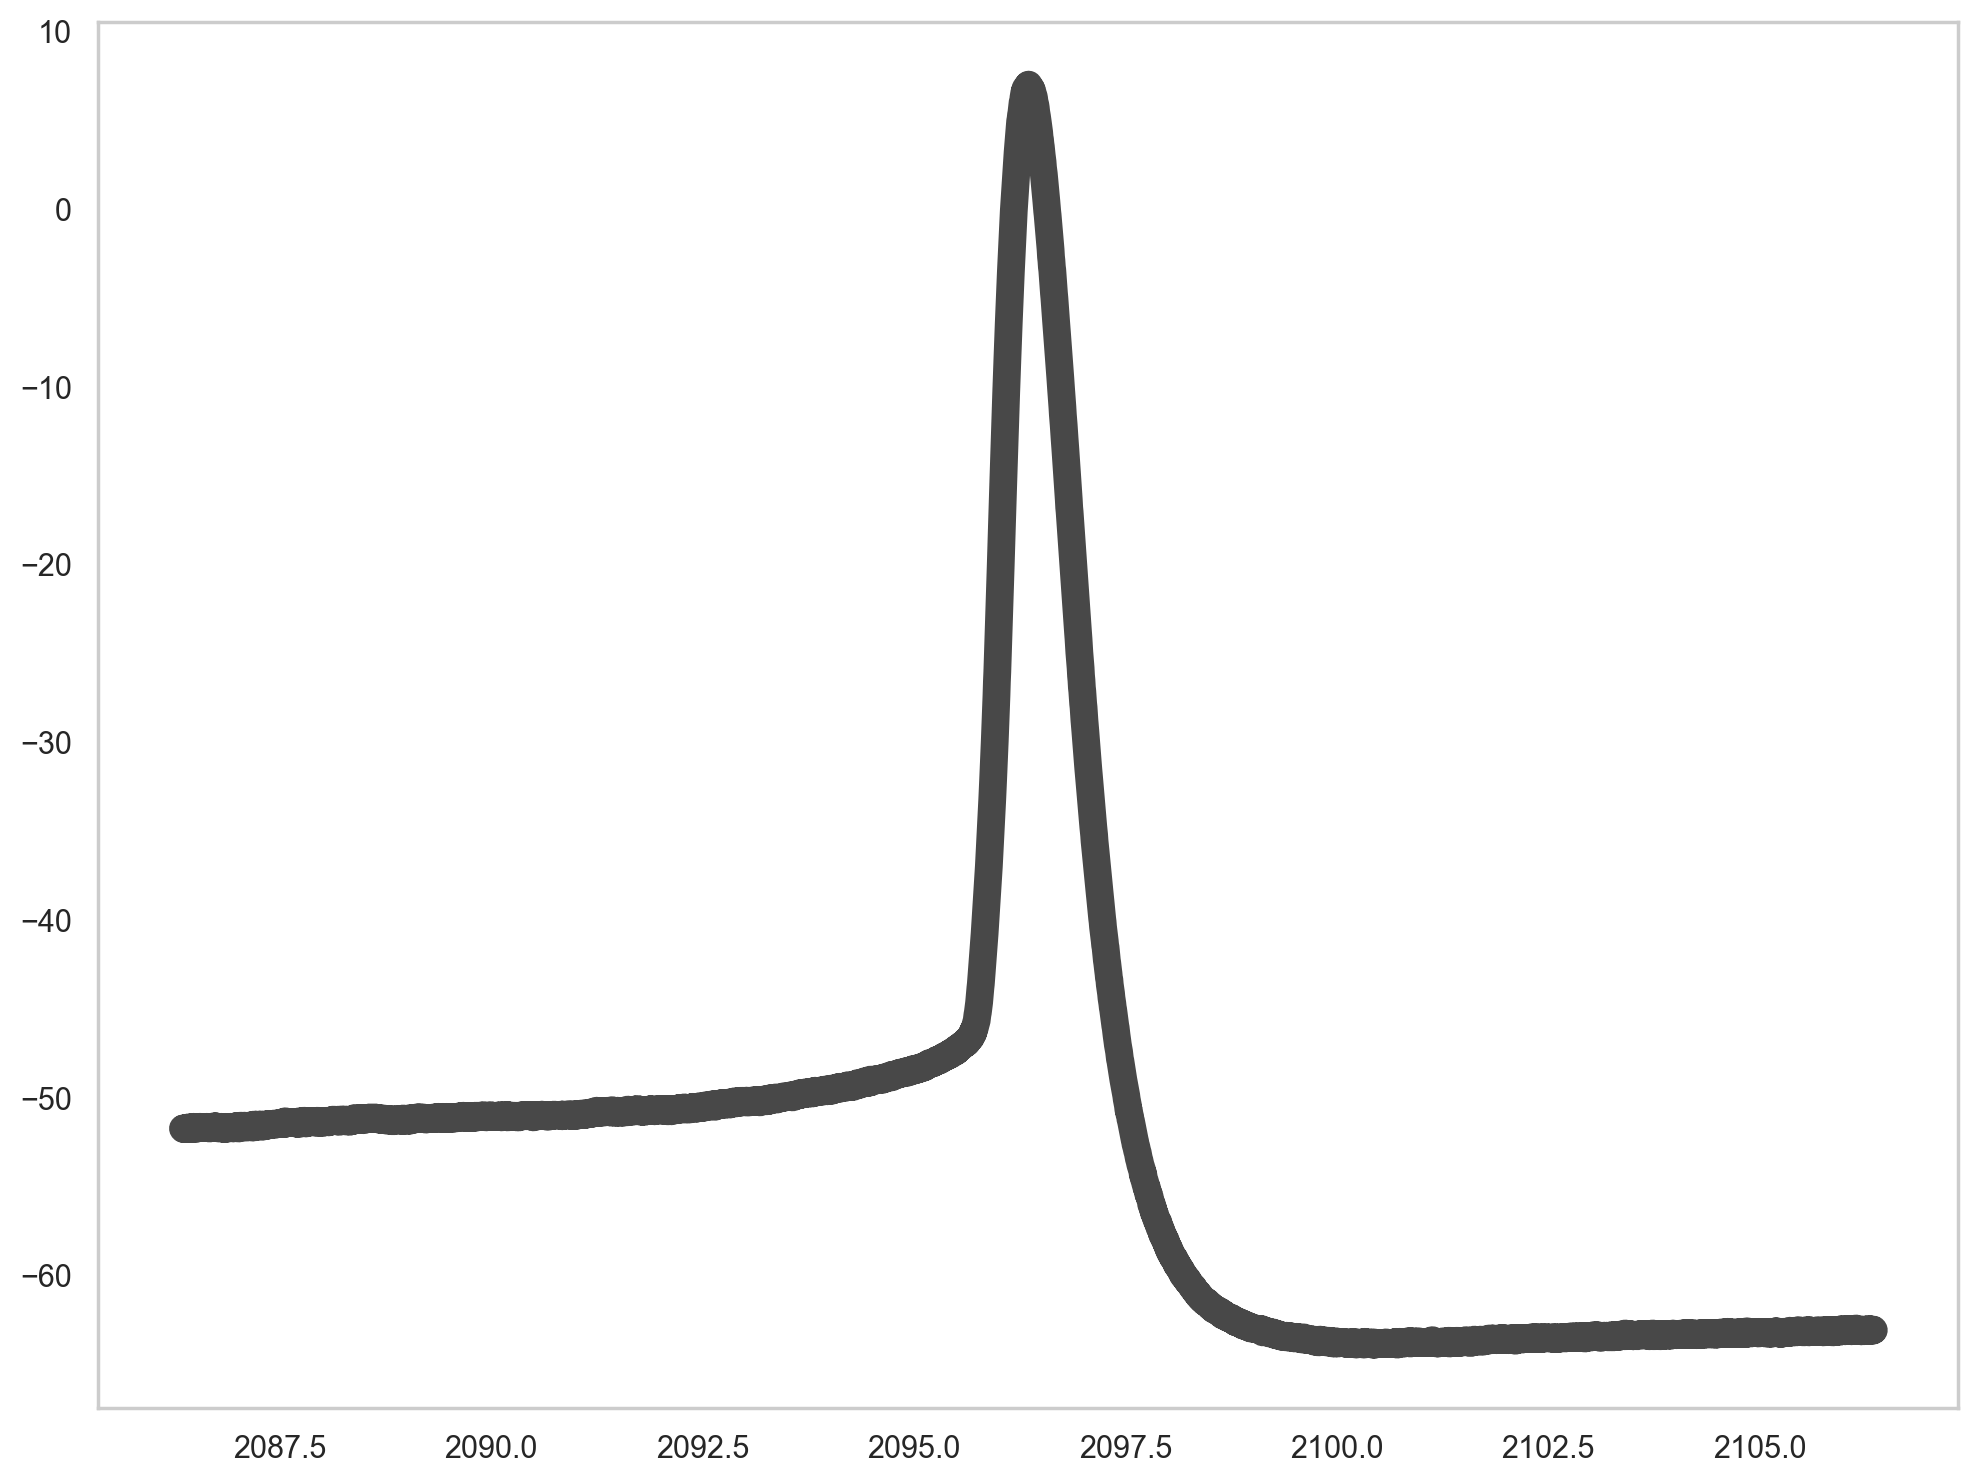

In [13]:
plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 10.,color='k')

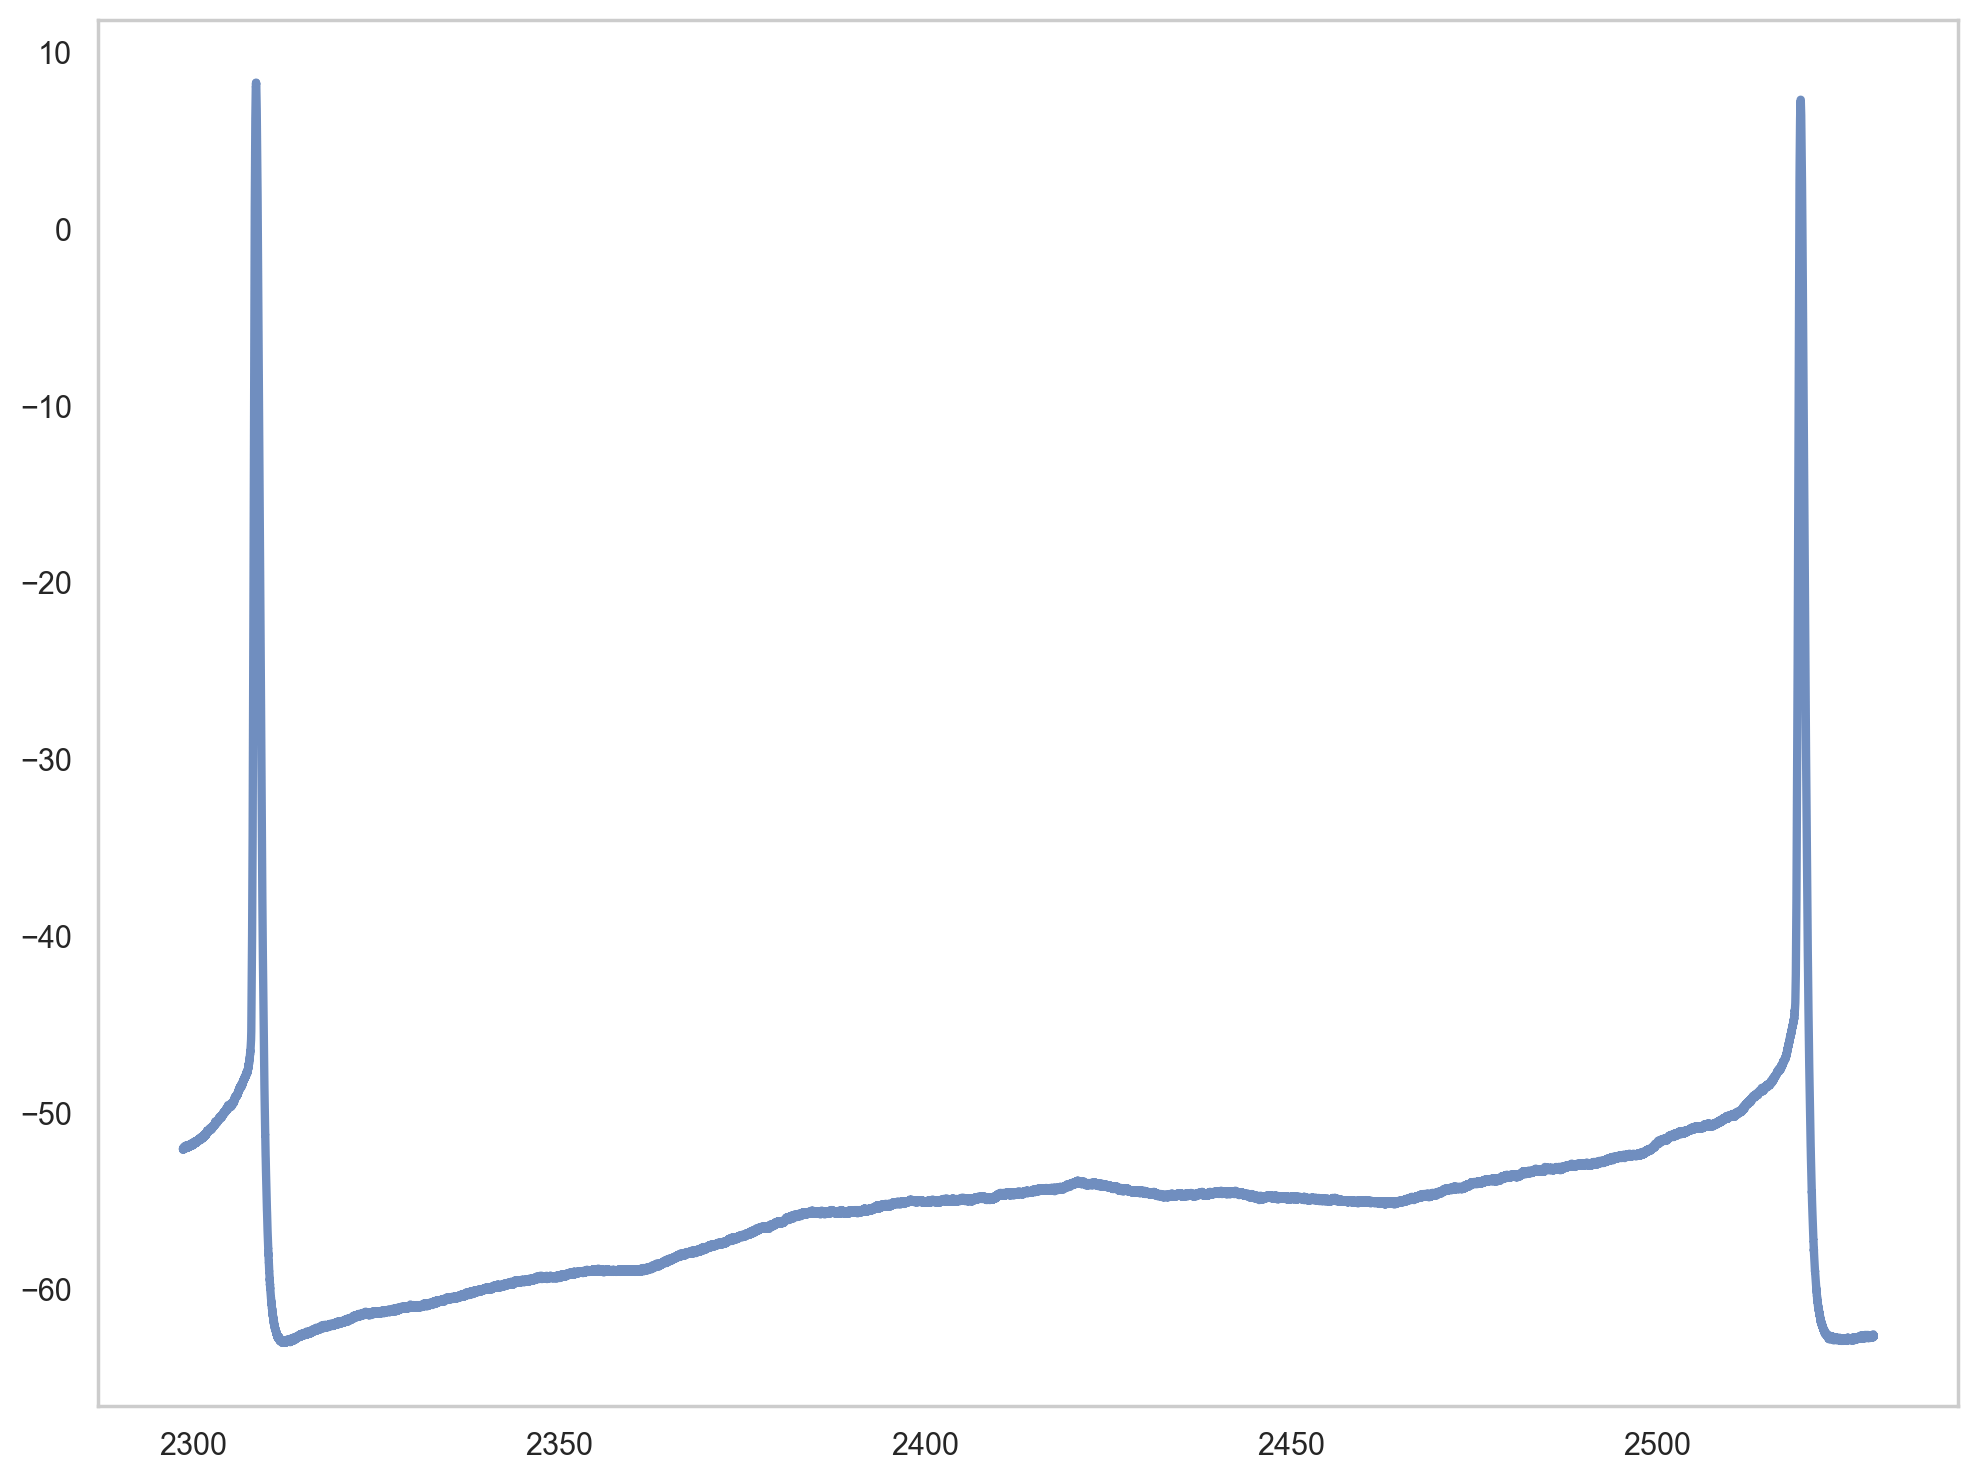

In [14]:
# Plot single spike, and its derivative

dset, times = load_sweep(14)

stim = dset[:, 0] # current injection
data = dset[:, 1] # ephys data



#########################
# find spikes
thresh_mv = -10
thresh_ms = one_ms * 1 # 1 ms

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)



#########################
i_spikes = 1
    
# get windows around spikes
# create window indices
window_length = (10, 10) # in ms
window_pre = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

# get window
window_spike_pre = (idx_spikes[i_spikes]-window_pre)
window_spike_post = (idx_spikes[2]+window_post)

# get window for times as well
windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                    (idx_spikes[2]+window_post)]

# get data window
windowed_data = data[window_spike_pre:window_spike_post]

# difference of data, and smooth it
d_windowed_data = np.diff(windowed_data)

toy_data = windowed_data
toy_times = windowed_times

plt.plot(toy_times, toy_data, 'b', alpha = 0.8, linewidth = 3., label='intra')



plt.show()

In [18]:
#recreate parameterization using the Spike class
#Run spikeparam on real EAPs 
sp_toy = Spike(thresh_amp=-10, window_length=(10, 10), smooth_frac=.01, )




sp_toy.fit(toy_data, fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/2 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


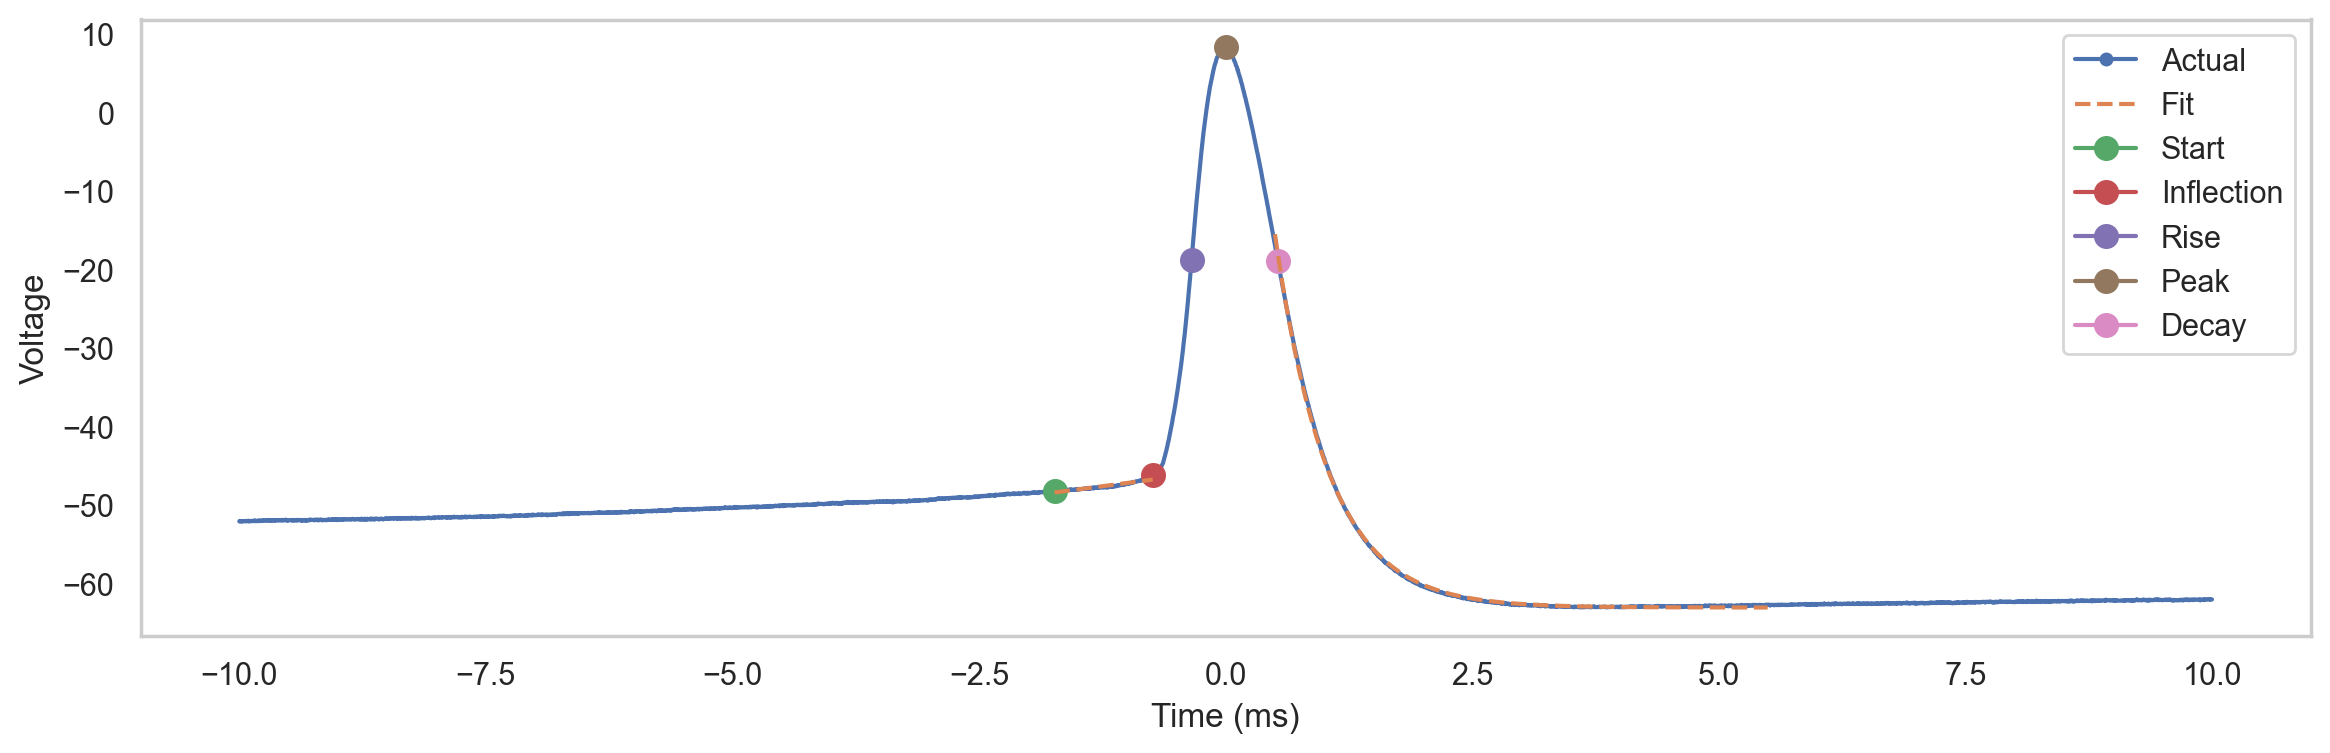

In [21]:
sp_toy.plot(show_points=True, inds=0)

In [19]:
sp_toy.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,1.645808,0.735,-46.281251,8.28125,0.875,1.96875,1.862159,-63.032804,211.04,0.906929,0.999571
1,2.057672,0.770,-44.187501,7.31250,0.910,1.71875,1.696215,-62.864505,NaN,0.989322,0.999630
